<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/lecture_1/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_1_%D0%9D%D0%B0%D1%81%D1%82%D1%80%D0%BE%D0%B9%D0%BA%D0%B0_%D1%80%D0%B0%D0%B1%D0%BE%D1%87%D0%B5%D0%B3%D0%BE_%D0%BE%D0%BA%D1%80%D1%83%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Практическое занятие. Настройка рабочего окружения: VS Code, Google Colab, Hugging Face, Kaggle

### 1. Введение

Представьте: вы нашли интересный код для анализа текстовых дневников, скопировали его в свой редактор, нажали «запустить» — и получили гору ошибок. Библиотеки не установлены, версии Python не совпадают, а на чужом компьютере всё работало. Знакомо?

Чтобы такого не происходило, data-специалисты используют **единое рабочее окружение** — набор инструментов и настроек, которые гарантируют, что код будет выполняться одинаково у всех, независимо от операционной системы или модели компьютера.

На этом занятии мы настроим два типа окружений:

1. **Облачное окружение — Google Colab.** Это бесплатный сервис от Google, который позволяет писать и выполнять Python-код прямо в браузере, без установки чего-либо на свой компьютер. Colab даёт доступ к **GPU** (графическому процессору) — это ускоряет обучение нейросетей в десятки раз [1]. Для новичков это идеальный старт.

2. **Локальное окружение — VS Code.** Это полноценный редактор кода, который устанавливается на ваш компьютер. Он подходит для тех, кто хочет работать офлайн или с большими объёмами данных, которые неудобно хранить в облаке [2].

Мы также зарегистрируемся на двух ключевых платформах: **Hugging Face** (библиотека готовых моделей и датасетов) и **Kaggle** (платформа для соревнований и работы с данными). Они понадобятся нам на следующих занятиях.


### 2. Регистрация и получение API-ключей

Прежде чем писать код, нужно получить доступ к платформам, откуда мы будем брать модели и данные.

#### 2.1. Hugging Face: регистрация и Access Token

**Hugging Face** — это платформа, где собраны тысячи готовых моделей для работы с текстом (анализ тональности, генерация, классификация) и датасетов. Чтобы скачивать их программно, нужен **Access Token** — что-то вроде цифрового ключа, который подтверждает вашу личность [3].

**Пошаговая инструкция:**

1. Перейдите на сайт [huggingface.co](https://huggingface.co) и зарегистрируйтесь (кнопка **Sign Up**).


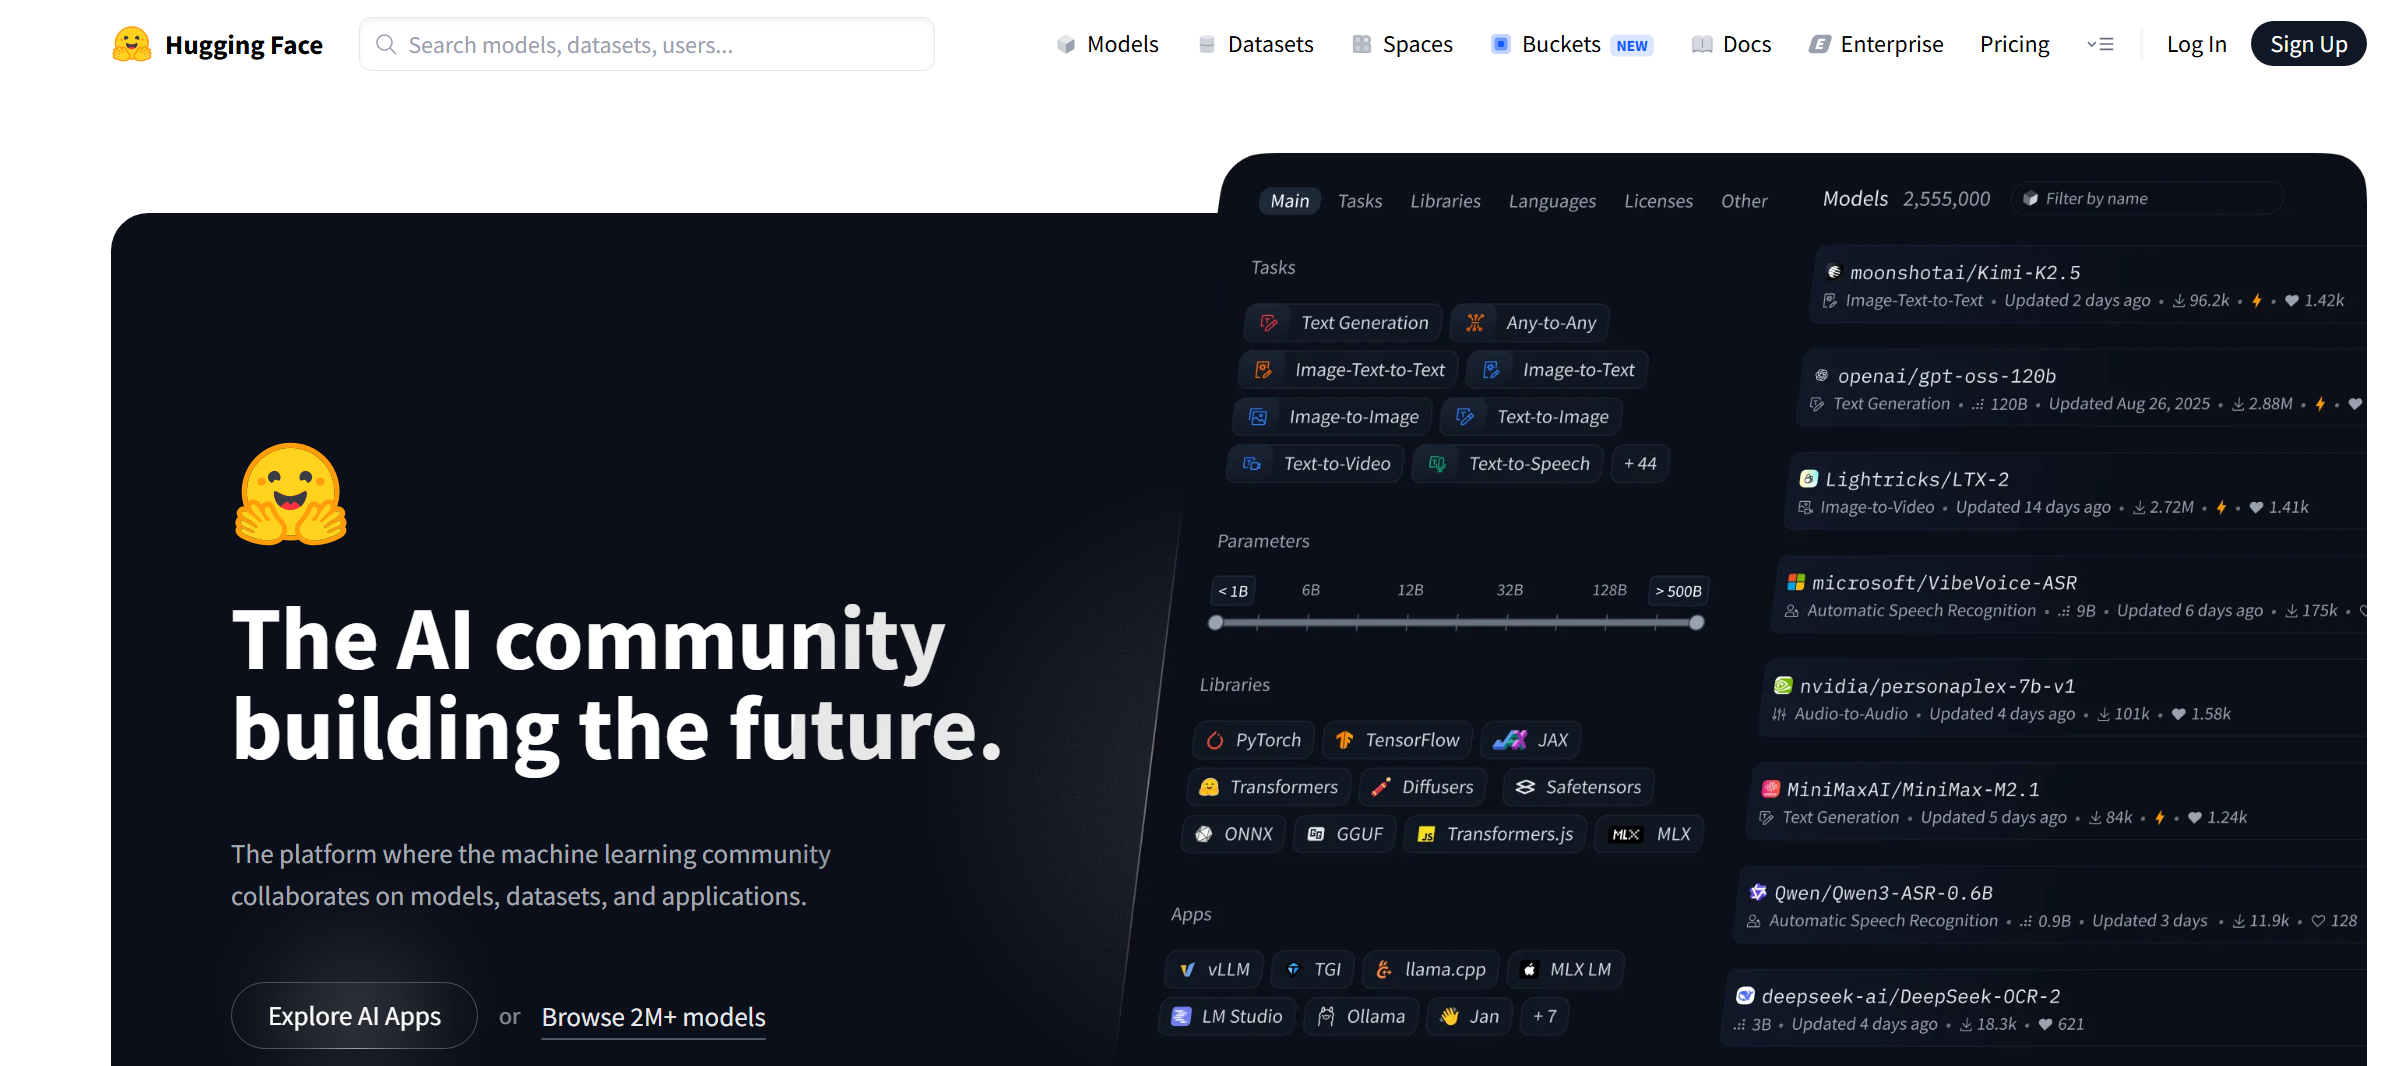


2. После входа кликните на свой аватар в правом верхнем углу → выберите **Settings**.


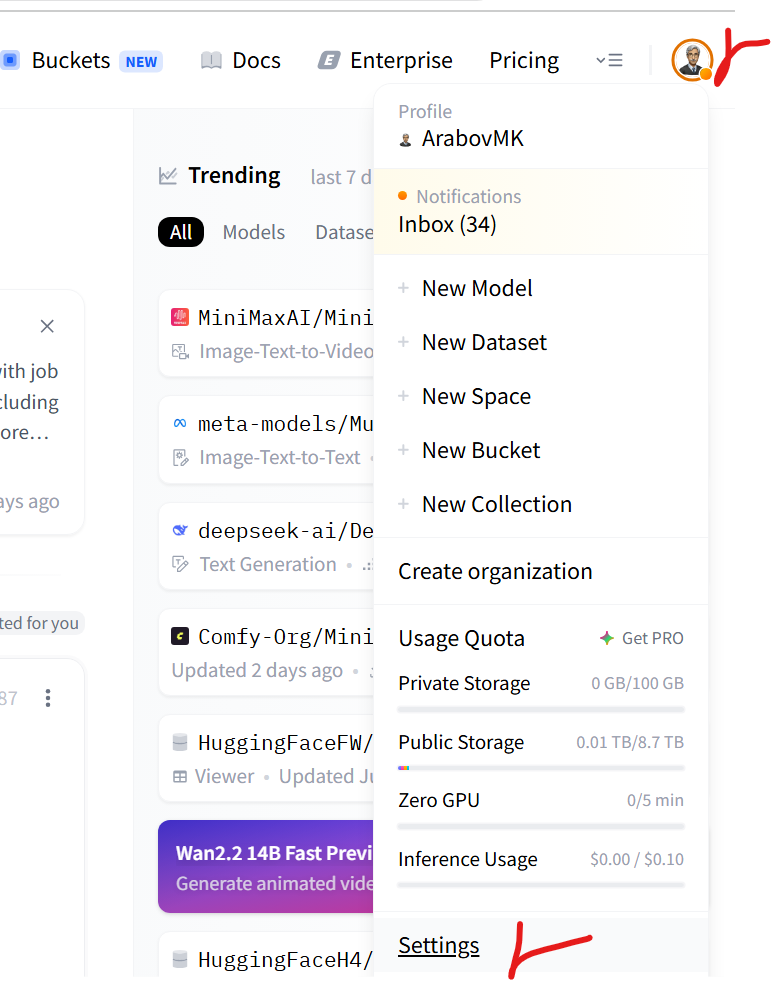


3. В левом меню выберите **Access Tokens**.


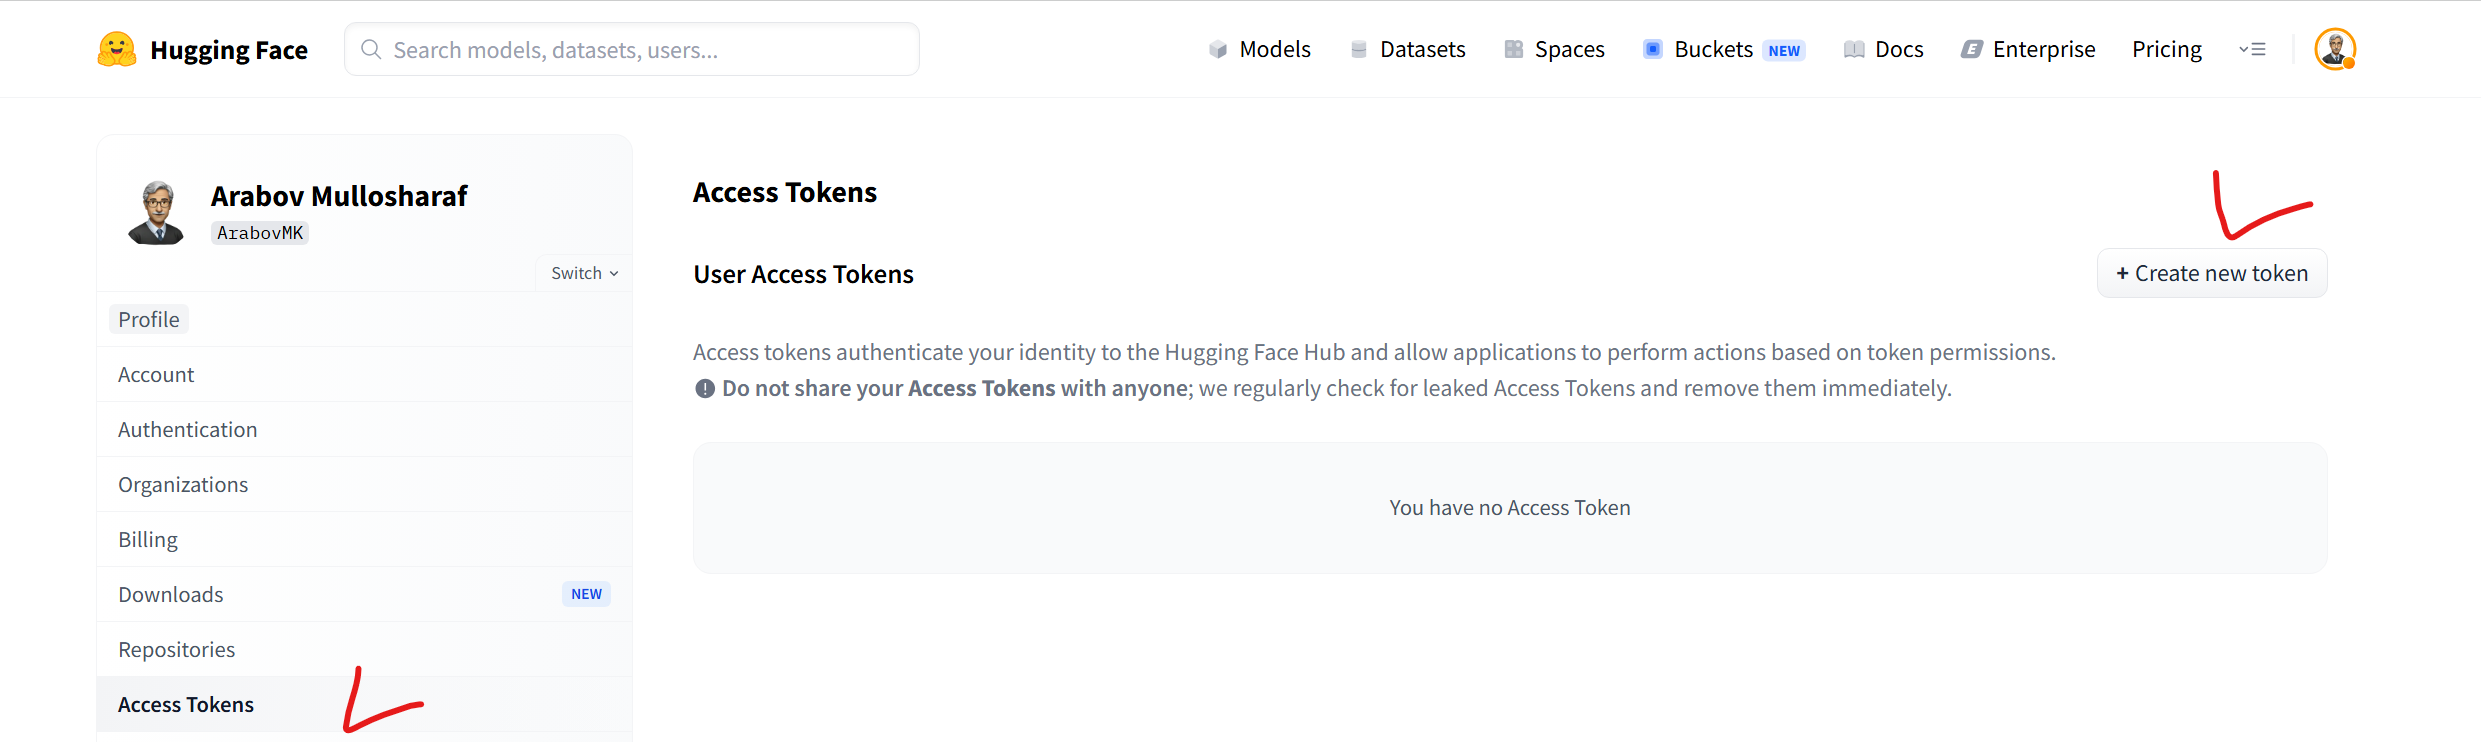


4. Нажмите **New token**. Дайте токену имя (например, `my_psych_token`) и выберите тип доступа **Read** — этого достаточно для скачивания моделей и датасетов [3].

5. Нажмите **Generate token** и **скопируйте** полученный токен в надёжное место.



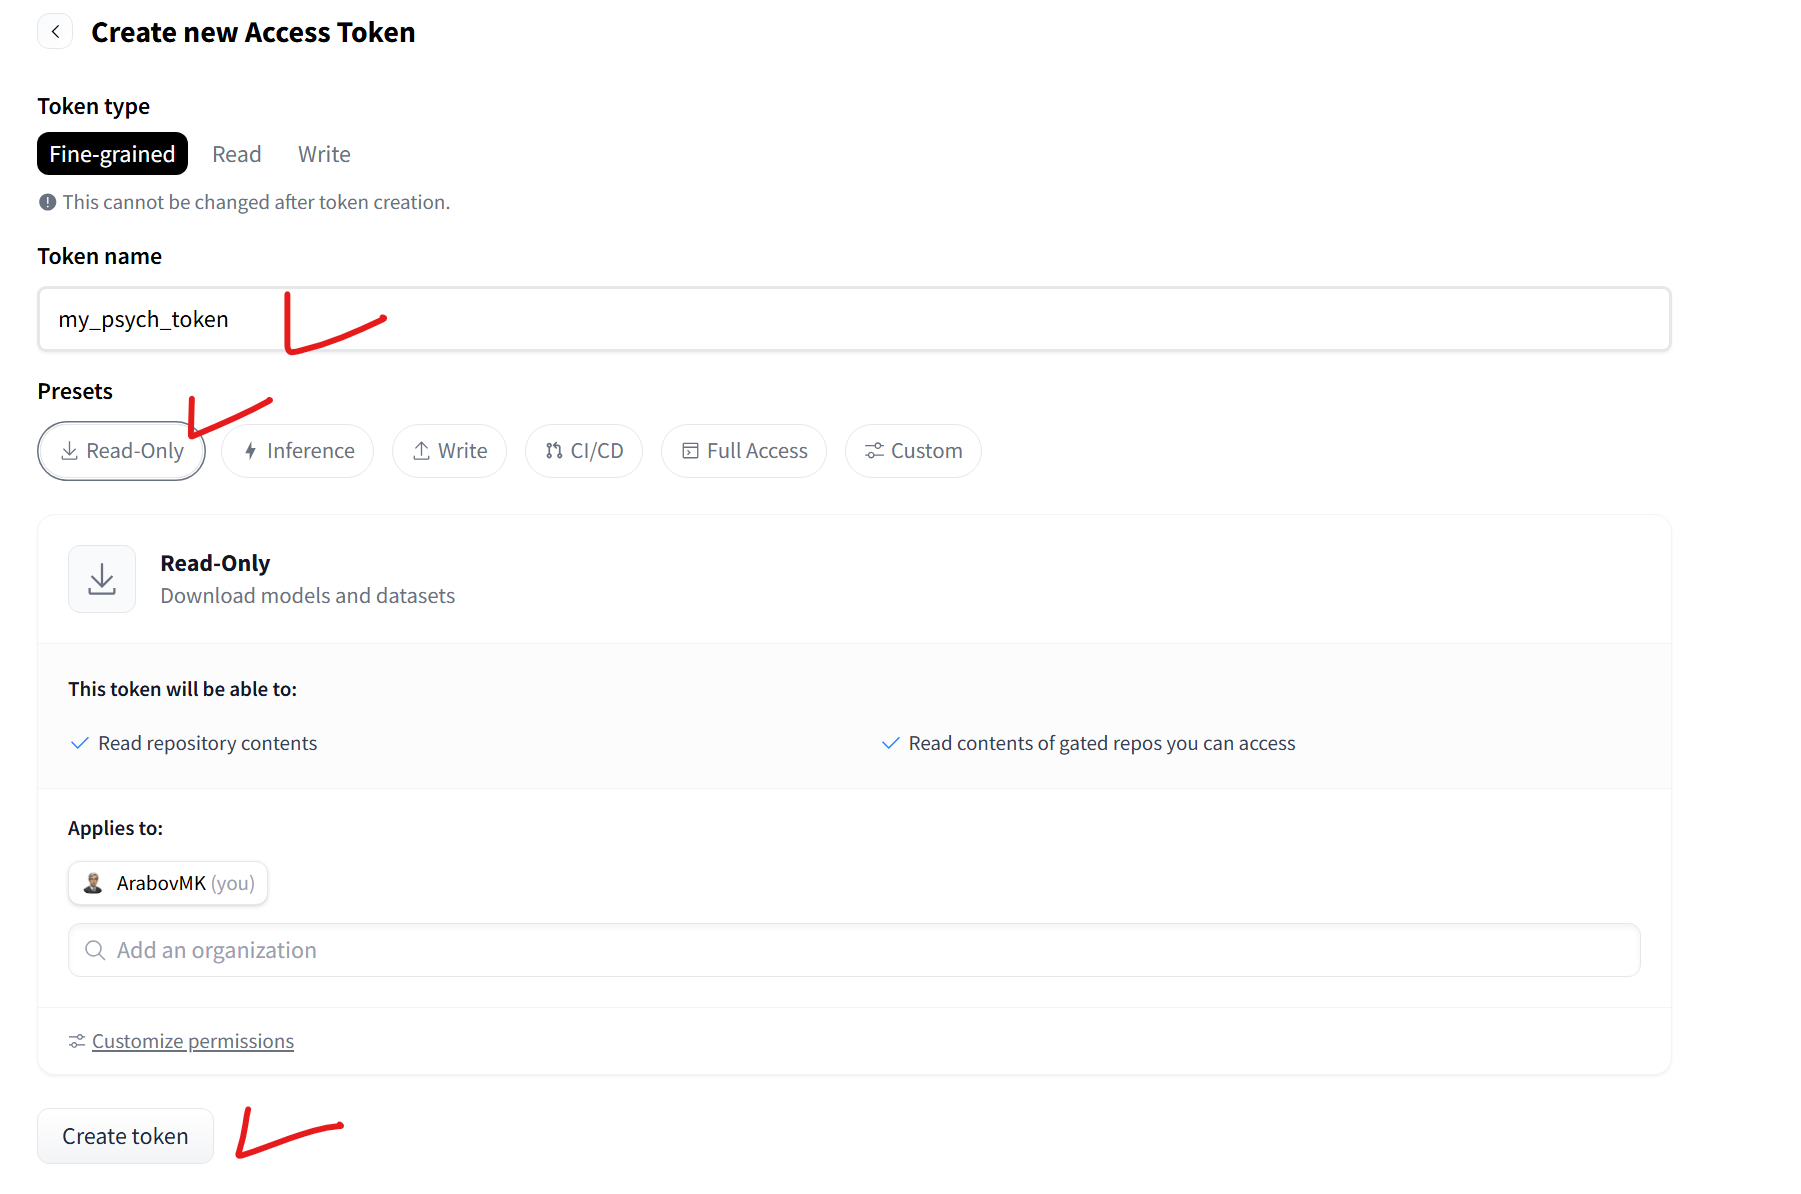


⚠️ **Важно:** токен — это ваш цифровой ключ. **Никогда не публикуйте его в открытых репозиториях, чатах или в коде, который выкладываете в интернет.** В реальных проектах токены хранят в переменных окружения или менеджерах секретов.

В Google Colab вход в Hugging Face выполняется одной командой:

```python
from huggingface_hub import login
login(token="ваш_токен")
```

Либо можно использовать интерактивный режим:

```python
from huggingface_hub import login
login()
```

Система попросит ввести токен — вставьте его и нажмите Enter [3].

**Альтернатива для Colab:** используйте панель **Secrets** (значок 🔑 в левом меню). Создайте секрет `my_psych_token` со значением вашего токена, а затем в коде:



**Как это работает:**

1. В левом меню Colab нажмите на значок ключа (**Secrets**).
2. Нажмите **Add new secret**.
3. В поле **Name** введите `my_psych_token` (или любое другое имя).
4. В поле **Value** вставьте ваш Access Token.



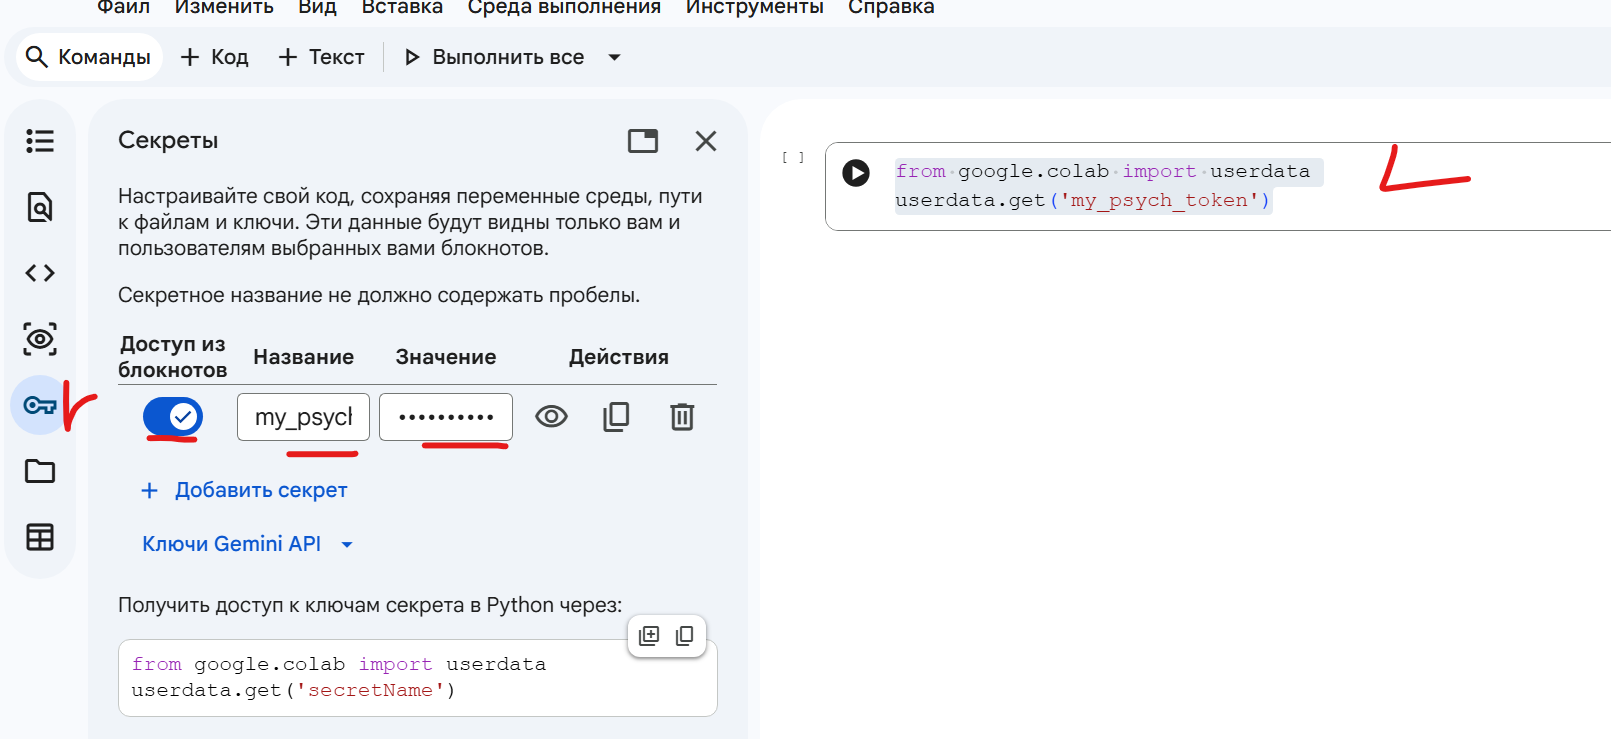

 Теперь в коде вы можете получить этот ключ безопасно:

```python
from google.colab import userdata
userdata.get('my_psych_token')
```

**Пример авторизации в Hugging Face через Secrets:**

```python
from huggingface_hub import login
from google.colab import userdata

# Токен хранится в Secrets под именем HF_TOKEN
login(token=userdata.get('my_psych_token'))
```

Этот подход:
- **Безопаснее** — токен не виден в коде и не сохраняется в истории блокнота.
- **Удобнее** — не нужно каждый раз вводить токен вручную.
- **Переносимее** — вы можете делиться блокнотом, не опасаясь, что токен попадёт в чужие руки.






#### 2.2. Kaggle: доступ через kagglehub

Ранее для работы с Kaggle требовался API-ключ в формате `kaggle.json`. Теперь это стало проще благодаря библиотеке **kagglehub** — она автоматически управляет аутентификацией и скачиванием [7].

**Установка kagglehub:**




In [ ]:
!pip install kagglehub


**Для доступа к публичным датасетам** аутентификация не требуется. Например, скачаем датасет с индексами счастья (World Happiness Report):




In [ ]:
import kagglehub
import pandas as pd
import os

# Скачивание датасета
path = kagglehub.dataset_download("unsdsn/world-happiness")

# Посмотрим, какие файлы есть
print("Файлы в папке:", os.listdir(path))

# Обычно там есть 2019.csv
csv_path = os.path.join(path, "2019.csv")

# Читаем первые 5 записей
df = pd.read_csv(csv_path)
print(df.head())


**Для доступа к закрытым датасетам или соревнованиям** (например, Titanic) требуется аутентификация через `kagglehub.login()`:

```python
import kagglehub

# Авторизация (откроется окно браузера для входа)
kagglehub.login()

# Скачивание датасета соревнования
path = kagglehub.competition_download('titanic')
print("Файлы Titanic:", os.listdir(path))
```

**Для скачивания готовых моделей** с Kaggle (например, DeepSeek R1):

```python
import kagglehub

# Скачивание модели DeepSeek R1
path = kagglehub.model_download('deepseek-ai/deepseek-r1/transformers/deepseek-r1/1')
print("Модель загружена в:", path)
```

Обратите внимание на структуру пути: `'владелец/название_модели/фреймворк/вариация/версия'`.

#### 2.3. Сравнение способов работы с Kaggle

| Способ | Что нужно | Когда использовать |
|--------|-----------|-------------------|
| **kagglehub.login()** | Логин в браузере | Для закрытых датасетов и соревнований [7] |
| **dataset_download()** | Только имя датасета | Для публичных датасетов (без аутентификации) |
| **competition_download()** | Авторизация через `login()` | Для загрузки данных соревнований |
| **model_download()** | Авторизация через `login()` | Для скачивания готовых моделей |


### 3. Выбор и настройка среды

Теперь переходим к настройке основного рабочего пространства.

#### 3.1. Google Colab (облачный вариант)

Colab — это Jupyter-блокнот в браузере. Все файлы и код хранятся на Google Диске, а вычисления выполняются на серверах Google. Для начала работы вам понадобится только браузер и учётная запись Google.

**Регистрация и вход в систему:**

Чтобы использовать Colab, вам потребуется **учётная запись Google** (Gmail). Если у вас её нет, её можно создать бесплатно на странице регистрации Google.

**Пошаговая инструкция:**

1. Откройте браузер и перейдите на официальный сайт: [colab.research.google.com](https://colab.research.google.com) [1].
2. Нажмите на синюю кнопку **«Войти»** (Sign In) в правом верхнем углу экрана.
3. Введите адрес своей электронной почты Gmail и пароль.
4. После успешного входа вы попадете на стартовую страницу Colab. Здесь можно создать новый блокнот, открыть недавние файлы или загрузить существующий блокнот с компьютера или из Google Диска.
5. Чтобы создать новый блокнот, нажмите кнопку **«Создать новый блокнот»** (или **New Notebook**) в нижней части окна.

**Настройка типа оборудования (CPU / GPU):**

По умолчанию Colab использует **CPU** (центральный процессор) для вычислений. Однако для большинства задач, связанных с нейросетями и глубоким обучением, необходимо использовать **GPU** (графический процессор), так как он может ускорить вычисления в десятки раз. Переключение режима выполняется за несколько кликов:

1. В открытом блокноте перейдите в верхнее меню и выберите **«Среда выполнения»** (Runtime).
2. В выпадающем меню выберите **«Изменить тип среды выполнения»** (Change runtime type).



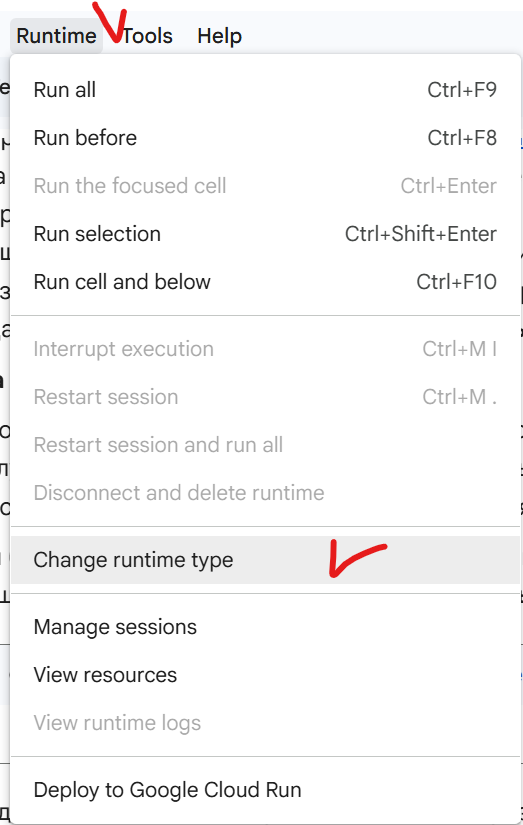


3. Откроется диалоговое окно «Настройки блокнота». В разделе **«Аппаратный ускоритель»** (Hardware accelerator) выберите из выпадающего списка нужный вариант.



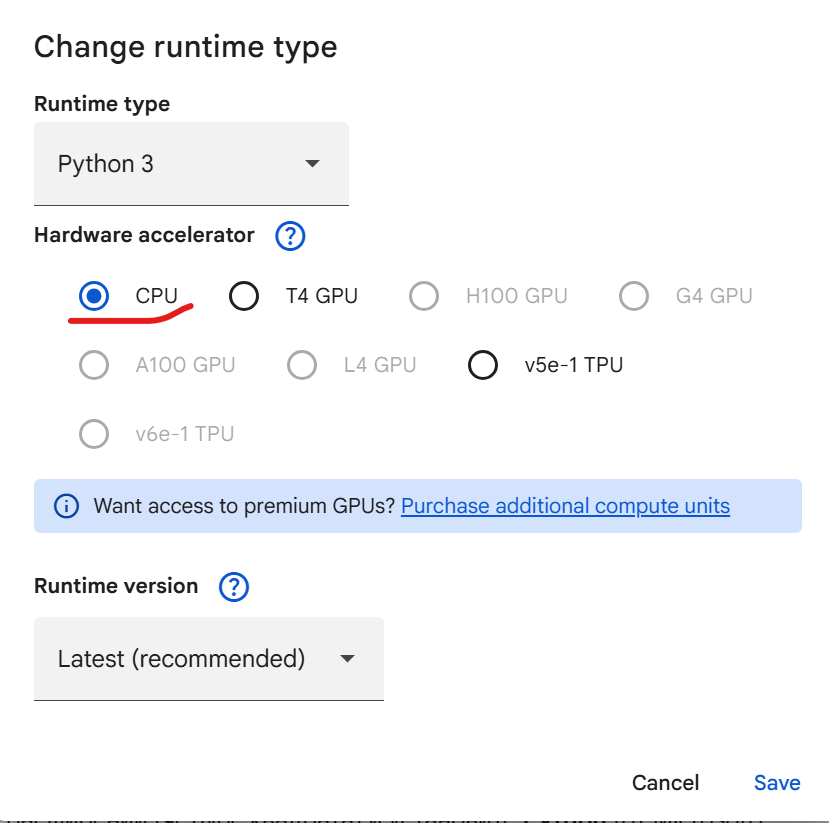


**Что означают эти опции (для не-технических специалистов):**

| Опция | Что это | Для чего нужно | Когда использовать |
|-------|---------|----------------|-------------------|
| **None (CPU)** | Центральный процессор — «мозг» компьютера, который выполняет все основные операции. | Подходит для простых вычислений: работа с таблицами, визуализация, базовый Python-код. | Когда вы только начинаете или если ваш код не требует больших вычислительных мощностей. |
| **T4 GPU** | Графический процессор NVIDIA T4 — специализированный чип для параллельных вычислений. Бесплатный вариант Colab. | Ускоряет обучение нейросетей, обработку изображений, работу с большими языковыми моделями. | **Стандартный выбор для большинства задач по ИИ.** Доступен в бесплатной версии. |
| **H100 GPU** | Флагманский графический процессор NVIDIA H100 — самый мощный на рынке. | Для самых тяжёлых задач: обучение огромных моделей, сложные симуляции. | Доступен только в платной подписке Colab Pro/Pro+. Обычно не требуется для учебных задач. |
| **G4 GPU** | Устаревшая модель графического процессора. | Редко используется сейчас. | Не рекомендуется — лучше выбрать T4 или L4. |
| **A100 GPU** | Мощный графический процессор NVIDIA A100 — используется в дата-центрах. | Для серьёзных исследовательских задач и работы с очень большими данными. | Доступен в платных версиях. Для учебных задач обычно избыточен. |
| **L4 GPU** | Современный графический процессор NVIDIA L4 — оптимизирован для инференса (запуска готовых моделей). | Для развертывания и запуска уже обученных моделей, работы с видео и изображениями. | Хороший выбор, если вы не обучаете модель с нуля, а только используете готовые. |
| **v5e-1 TPU / v6e-1 TPU** | Тензорные процессоры от Google — специальные чипы, созданные для ускорения нейросетей. | Могут быть очень быстрыми для специфических задач в TensorFlow. | Используются редко, так как большинство моделей в психологии работают через PyTorch, который не всегда оптимален для TPU. |

> **Важно:** Смена типа оборудования **перезапустит среду выполнения**. Это означает, что все запущенные ранее ячейки кода будут остановлены, а переменные в памяти будут сброшены. Поэтому переключать режим лучше **до** начала выполнения кода.

**Рекомендация для студентов-психологов:**
- Для начала работы и выполнения всех заданий курса выбирайте **T4 GPU** — это оптимальный баланс между мощностью и доступностью.
- Если вы работаете с небольшими датасетами и простыми моделями, можно оставить **None (CPU)** — это сэкономит квоту на использование GPU в Colab.
- Платные варианты (H100, A100) для учебных задач не нужны.

Проверить, какой ускоритель используется в данный момент, можно также с помощью кода на Python, как показано далее в этом руководстве.






#### 3.2. VS Code (локальный вариант)

**VS Code** (Visual Studio Code) — это бесплатный редактор кода от Microsoft. Он легковесный, но мощный за счёт расширений. Мы будем использовать его как основную среду для написания и запуска Python-кода на вашем компьютере.

**Установка VS Code (первый шаг):**

1. Перейдите на официальный сайт [code.visualstudio.com](https://code.visualstudio.com) [2] и скачайте установщик для вашей операционной системы (Windows, macOS или Linux).
2. Запустите установщик и следуйте инструкциям на экране. На Windows рекомендуется оставить все настройки по умолчанию.
3. Запустите VS Code. В левой панели нажмите на иконку расширений (четыре квадрата) и установите расширение **Python** (от Microsoft) — оно добавит подсветку синтаксиса, автодополнение и возможность запуска кода.

**Установка Python (второй шаг):**

VS Code — это только редактор. Чтобы он мог выполнять код, нужен сам **Python** — язык программирования. Без него VS Code будет просто текстовым редактором.

> 💡 **Рекомендация для новичков:** устанавливайте Python через **Microsoft Store** — это самый простой и надёжный способ. Store автоматически настраивает все пути (PATH), следит за обновлениями и гарантирует совместимость с Windows [9].

**Какая версия Python нужна?**

На момент написания руководства (2026 год) последняя версия — **Python 3.13**. Однако **для совместимости с библиотеками машинного обучения рекомендуется устанавливать Python 3.11 или 3.12**.

| Версия | Статус | Рекомендация |
|--------|--------|--------------|
| **Python 3.11** | Стабильная, проверенная | ✅ **Настоятельно рекомендуется** — все библиотеки работают без проблем. |
| **Python 3.12** | Стабильная, современная | ✅ **Хороший выбор** — большинство библиотек уже поддерживают. |
| **Python 3.13** | Новейшая | ⚠️ Не рекомендуется — часть библиотек могут быть ещё несовместимы. |

**Пошаговая инструкция по установке Python (через Microsoft Store):**

1. Откройте **Microsoft Store** на вашем компьютере (значок в виде пакета на панели задач или в меню «Пуск»).
2. В строке поиска введите `Python`.
3. В результатах поиска найдите нужную версию, например **Python 3.11** или **Python 3.12** (обратите внимание на номер версии в названии).
4. Нажмите кнопку **«Установить»** (или «Получить»).
5. Дождитесь завершения установки — это займёт 1–2 минуты.

**Альтернативный способ (с официального сайта):**

Если по какой-то причине Microsoft Store недоступен, можно скачать установщик с официального сайта [python.org/downloads](https://python.org/downloads) [9]. При установке обязательно поставьте галочку **«Add Python to PATH»**.

**Проверка установки:**

После установки Python откройте новый терминал в VS Code: **Terminal** → **New Terminal** (или `Ctrl + ``). Выполните:

```bash
python --version
```

Вы должны увидеть что-то вроде: `Python 3.11.9` (или другой номер версии).

**Создание виртуального окружения:**

Виртуальное окружение — это изолированная среда для каждого проекта, где библиотеки устанавливаются отдельно, не мешая другим проектам. Это стандарт в разработке на Python.

1. В VS Code создайте папку для проекта: **File** → **Open Folder** → создайте папку, например, `psych_ai_course`, и откройте её.
2. Откройте терминал: **Terminal** → **New Terminal**.
3. Убедитесь, что Python установлен и доступен:

```bash
python --version
```

4. Создайте виртуальное окружение:

```bash
python -m venv .venv
```

Эта команда создаст папку `.venv` с изолированным Python.

**Активация окружения:**

- **Windows** (PowerShell):
  ```bash
  .venv\Scripts\Activate
  ```
- **macOS / Linux**:
  ```bash
  source .venv/bin/activate
  ```

После активации в начале строки терминала появится `(.venv)` — это признак, что окружение активно.

В VS Code можно выбрать интерпретатор автоматически: нажмите `Ctrl+Shift+P` → **Python: Select Interpreter** → выберите `.venv` из списка.

**Работа с Jupyter в VS Code:**

В VS Code тоже можно открывать и выполнять `.ipynb`-блокноты (как в Colab). Для этого установите расширение **Jupyter** (входит в пакет Python от Microsoft). После этого вы сможете создавать блокноты (`Ctrl+Shift+P` → **Create: New Jupyter Notebook**) и выполнять ячейки прямо в редакторе — это удобно, если вы хотите совмещать локальную мощь с интерфейсом блокнотов.



#### 3.3. Установка библиотек

Библиотеки — это готовые наборы кода, которые расширяют возможности Python. Мы установим все необходимые для курса разом.

В терминале (локально) выполните:

```bash
pip install pandas matplotlib seaborn scikit-learn transformers datasets sentence-transformers chromadb streamlit gradio torch ollama langchain kagglehub
```

В Colab предпочтительнее использовать `%pip` — это магическая команда, которая лучше обрабатывает зависимости внутри окружения блокнота:

```python
%pip install pandas matplotlib seaborn scikit-learn transformers datasets sentence-transformers chromadb streamlit gradio torch ollama langchain kagglehub
```

Оба способа (`!pip` и `%pip`) работают, но `%pip` считается более современным для Colab.

**Что даёт каждая библиотека:**
- **pandas** — работа с таблицами (данными).
- **matplotlib, seaborn** — визуализация графиков.
- **scikit-learn** — классические алгоритмы машинного обучения.
- **transformers, datasets** — модели и датасеты от Hugging Face [4].
- **sentence-transformers** — модели для преобразования текста в векторы.
- **chromadb** — векторная база данных для хранения эмбеддингов.
- **streamlit, gradio** — создание веб-интерфейсов для демонстрации моделей.
- **torch** — PyTorch, фреймворк для глубокого обучения [6].
- **ollama** — запуск больших языковых моделей локально.
- **langchain** — создание цепочек из моделей и данных.
- **kagglehub** — удобная загрузка данных и моделей с Kaggle [7].


### 4. Проверка работоспособности и тестовый запуск

Теперь убедимся, что всё настроено правильно.

#### 4.1. Проверка GPU

В Colab или локально выполните:

```python
import torch
print(torch.cuda.is_available())
```

Если вывод — `True`, значит GPU подключён и готов к работе. Если `False` — проверьте, что в Colab выбран GPU в настройках Runtime, или что у вас установлена версия PyTorch с поддержкой CUDA [5].

**Для любопытных:** в Colab можно выполнить команду `!nvidia-smi` — она покажет модель вашего GPU и текущую загрузку. Это даёт ощущение «прикосновения» к реальному оборудованию.

```python
!nvidia-smi
```

#### 4.2. Тестовая программа

Создайте ячейку и выполните:

```python
print("Hello, Psychologist! Ваше окружение работает.")
```

Если вы видите это сообщение — Python настроен корректно.

#### 4.3. Загрузка первого датасета из Hugging Face

Датасет — это набор данных, на котором мы будем тренировать и тестировать модели. Загрузим датасет **emotion** — он содержит английские предложения с метками эмоций (радость, грусть, гнев и т.д.).

```python
from datasets import load_dataset

dataset = load_dataset("emotion")
print(dataset)
```

Вы должны увидеть структуру датасета: три раздела — `train`, `validation`, `test`. Теперь посмотрим на первые три примера:

```python
print(dataset["train"][:3])
```

Этот код выведет три предложения и соответствующие им эмоции.

Преобразуем датасет в таблицу pandas и сохраним в CSV (это пригодится для анализа):

```python
import pandas as pd

df = pd.DataFrame(dataset["train"])
df.to_csv("emotion_train.csv", index=False)
print("Датасет сохранён как emotion_train.csv")
```

#### 4.4. Загрузка датасета из Kaggle через kagglehub

Как упоминалось в разделе 2.2, самый простой способ загрузить публичный датасет — использовать `kagglehub.dataset_download()`. Загрузим датасет **World Happiness** (индекс счастья по странам):

```python
import kagglehub
import pandas as pd
import os

# Скачивание датасета
path = kagglehub.dataset_download("unsdsn/world-happiness")
print("Файлы в папке:", os.listdir(path))

csv_path = os.path.join(path, "2019.csv")
df = pd.read_csv(csv_path)
print(df.head())
```

Для загрузки данных соревнования Titanic (требуется авторизация):

```python
import kagglehub

# Авторизация
kagglehub.login()

# Скачивание данных соревнования
path = kagglehub.competition_download('titanic')
print("Файлы Titanic:", os.listdir(path))
```

Для загрузки готовой модели DeepSeek R1:

```python
import kagglehub

path = kagglehub.model_download('deepseek-ai/deepseek-r1/transformers/deepseek-r1/1')
print("Модель загружена в:", path)
```


### 5. Заключение

Поздравляю! Вы настроили рабочее окружение, которое будет служить фундаментом для всех дальнейших практических занятий.

**Краткое резюме выполненных шагов:**
1. Зарегистрировались на Hugging Face и получили Access Token (с правилами безопасности).
2. Настроили доступ к Kaggle через библиотеку kagglehub (с авторизацией через `login()` при необходимости).
3. Выбрали и настроили среду: Google Colab (облачный) или VS Code (локальный) с виртуальным окружением.
4. Установили все необходимые библиотеки одной командой.
5. Проверили GPU и выполнили тестовый код.
6. Загрузили датасет из Hugging Face и сохранили его в CSV.
7. Познакомились с kagglehub для загрузки датасетов, соревнований и моделей.

Теперь у вас есть полностью рабочее окружение для всех последующих практик. В следующий раз мы будем анализировать тексты с помощью моделей, которые вы скачаете из Hugging Face или Kaggle.

Документация по всем установленным библиотекам доступна по ссылкам из списка литературы — рекомендую изучить их для углублённого понимания.


### 6. Вопросы для самопроверки

1. Чем Google Colab отличается от локальной установки VS Code? В каких случаях стоит выбрать каждый из вариантов?

2. Что такое Access Token в Hugging Face и для чего он нужен? Как правильно хранить токен, чтобы не скомпрометировать его?

3. Как проверить, подключён ли GPU в Colab? Какая команда покажет модель и загрузку GPU?

4. Как установить библиотеку через `pip` в терминале и чем это отличается от установки в Colab? Почему в Colab рекомендуют использовать `%pip` вместо `!pip`?

5. Что такое виртуальное окружение и зачем оно нужно?

6. Как загрузить датасет из Hugging Face с помощью `load_dataset()`?

7. В чём преимущество библиотеки `kagglehub` по сравнению со старым способом работы с Kaggle API?

8. Что делает команда `kagglehub.login()` и когда она обязательна?

9. Какие три типа ресурсов можно скачивать через `kagglehub`? Приведите пример пути для каждого.

10. Как загрузить модель DeepSeek R1 с Kaggle?


### 7. Домашнее задание

**Часть 1. Сбор текстовых файлов (практическая)**

Создайте на Google Диске или в Colab папку `psych_books`. Загрузите туда 2–3 текстовых файла по психологии (только открытые источники: учебники, статьи, методические пособия). Напишите код, который выводит список файлов в этой папке и их размеры.

*Подсказка:* в Colab можно подключить Google Диск:
```python
from google.colab import drive
drive.mount('/content/drive')
```
Затем указать путь к папке.

**Часть 2. Работа с датасетами**

1. Загрузите датасет **emotion** из Hugging Face и сохраните его в CSV.
2. Загрузите датасет **World Happiness** с Kaggle через `kagglehub.dataset_download()` и выведите первые 3 строки.

**Часть 3. Отчёт по практике (1–2 страницы)**

Подготовьте краткий отчёт о проделанной работе. Включите:
- какие шаги были выполнены;
- какие возникли трудности и как вы их решили;
- скриншоты: успешная проверка GPU (`torch.cuda.is_available()` и `!nvidia-smi`), загрузка датасета emotion, загрузка датасета World Happiness с Kaggle.

**Часть 4. Рефлексия**

Ответьте на вопрос: *«Как вы думаете, почему единая среда так важна в командной работе над ИИ-проектами?»*

**Срок выполнения** — до следующего практического занятия.


### 8. Список литературы

1. Google Colab. (2025). *Welcome to Colaboratory*. URL: https://colab.research.google.com/

2. Visual Studio Code. (2025). *Documentation*. URL: https://code.visualstudio.com/

3. Hugging Face. (2025). *Hugging Face Hub Documentation*. URL: https://huggingface.co/docs/hub/index

4. Hugging Face. (2025). *Transformers Documentation*. URL: https://huggingface.co/docs/transformers/index

5. PyTorch. (2025). *CUDA Documentation*. URL: https://pytorch.org/docs/stable/notes/cuda.html

6. PyTorch. (2025). *Getting Started with PyTorch*. URL: https://pytorch.org/get-started/

7. Kaggle. (2025). *Kagglehub Documentation*. URL: https://github.com/Kaggle/kagglehub

8. Общая документация библиотек: pandas, matplotlib, seaborn, scikit-learn, datasets, sentence-transformers, chromadb, streamlit, gradio, ollama, langchain. Доступны на PyPI (https://pypi.org/) и официальных сайтах.